<a href="https://colab.research.google.com/github/caffein1371/Carrier-Owl/blob/master/atma2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [197]:
!apt-get -y install fonts-ipafont

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [198]:
!apt-get -y install fonts-ipafont-gothic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [199]:
!fc-list | grep "IPA"

/usr/share/fonts/opentype/ipafont-mincho/ipam.ttf: IPAMincho,IPA明朝:style=Regular
/usr/share/fonts/opentype/ipafont-gothic/ipagp.ttf: IPAPGothic,IPA Pゴシック:style=Regular
/usr/share/fonts/opentype/ipafont-mincho/ipamp.ttf: IPAPMincho,IPA P明朝:style=Regular
/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf: IPAGothic,IPAゴシック:style=Regular
/usr/share/fonts/truetype/fonts-japanese-mincho.ttf: IPAMincho,IPA明朝:style=Regular
/usr/share/fonts/truetype/fonts-japanese-gothic.ttf: IPAGothic,IPAゴシック:style=Regular


In [200]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# フォントのパスを指定
font_path = "/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf"  # ここを適宜変更
font_prop = fm.FontProperties(fname=font_path)

# Matplotlib のデフォルトフォントを設定
plt.rcParams["font.family"] = font_prop.get_name()

print(f"使用フォント: {font_prop.get_name()}")  # どのフォントが設定されたか確認


使用フォント: IPAGothic


In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

In [202]:
#オンライン EC サイト上の購買ログデータです。オフライン購買データ (train_session.csv / train_log.csv 他) とユーザー ID や購入セッション ID で紐づかないことに注意してください。
ec_df = pd.read_csv('/content/drive/MyDrive/atma/ec_log.csv')
#商品を一意に特定することができるコード (jan code) に対して、その商品の属性を記載しているデータです。
jan_df = pd.read_csv('/content/drive/MyDrive/atma/jan.csv')
#提出データの情報
test_session_df = pd.read_csv('/content/drive/MyDrive/atma/test_session.csv')
#学習期間の完全なオフライン購買データ。どの購入セッションで何を何円で何個かったか、の情報が記入されています
train_log_df = pd.read_csv('/content/drive/MyDrive/atma/train_log.csv')
#学習・テスト期間の購入セッションのメタ情報。学習期間とテスト期間は日付で分割されています。 2024-10-31 までが学習期間、それ以降がテスト期間です。
train_session_df = pd.read_csv('/content/drive/MyDrive/atma/train_session.csv')

train_target_df = pd.read_csv('/content/drive/MyDrive/atma/train_target.csv')

<ipython-input-202-b106b868f3a2>:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  ec_df = pd.read_csv('/content/drive/MyDrive/atma/ec_log.csv')


In [203]:
ec_df['JAN'].head()

,JAN
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [204]:
# CATEGORY 列の NaN 割合を計算
nan_ratio = ec_df['JAN'].isna().mean()

# 結果をパーセンテージで表示
print(f"JANが NaN の割合: {nan_ratio * 100:.2f}%")

JANが NaN の割合: 91.38%


In [205]:
# 'PURCHASED_AT'をpandasのdatetime型に変換し、タイムゾーンを無視して処理
ec_df['PURCHASED_AT'] = pd.to_datetime(ec_df['PURCHASED_AT'])

# タイムゾーンをローカル時間（日本時間）に変換（例：UTCから日本時間に）
ec_df['PURCHASED_AT'] = ec_df['PURCHASED_AT'].dt.tz_convert('Asia/Tokyo')

# 特徴量の抽出
ec_df['year'] = ec_df['PURCHASED_AT'].dt.year
ec_df['month'] = ec_df['PURCHASED_AT'].dt.month
ec_df['day'] = ec_df['PURCHASED_AT'].dt.day
ec_df['weekday'] = ec_df['PURCHASED_AT'].dt.weekday  # 0=月曜日, 6=日曜日
ec_df['hour'] = ec_df['PURCHASED_AT'].dt.hour
ec_df['minute'] = ec_df['PURCHASED_AT'].dt.minute
ec_df['second'] = ec_df['PURCHASED_AT'].dt.second

# 結果を表示
print(ec_df)

                                                   USER_ID  \
0        74aa584eddc336921bdac47fc6fe1ce970cfaeef3f2883...   
1        dd98b74fccc9331808a9e97cf56f02963fdd6cc2d9aad9...   
2        b078067564ee40e3813b95fad803cb9a2918bffc072b8e...   
3        2812f2353d41a98f57e11c782bf6de57f1942447fa1f73...   
4        bdda88ef299d4feec04c86b75d5188ea2dde37a807e26e...   
...                                                    ...   
1137693  189b6e4b5f1cb6fa32010cb3f9d3c615a5eba2f2ad1e69...   
1137694  a7402812267b3e7354b32bab5b1bee421004a723d1d80a...   
1137695  397c0aad63284317ff18fe4a6b908100077441b0f0339b...   
1137696  be4a884013416d1bb6a366f94e328c5f288c1326150c0a...   
1137697  b19a5f04b91b9e4939d0df134d36a1e70d6dbdf4f39f43...   

                     PURCHASED_AT EC_SITE_NAME  UNIT_PRICE  AMOUNT  AMOUNT_WB  \
0       2024-07-01 00:00:04+09:00      Rakuten      2699.0     1.0   0.465978   
1       2024-07-01 00:00:08+09:00      Rakuten     15000.0     1.0   0.906080   
2       2024

In [206]:
ec_df = ec_df[ec_df['AMOUNT_WB'].notna()]

In [207]:
# ec_df['JAN'] = ec_df['JAN'].astype(str)
# jan_df['JAN'] = jan_df['JAN'].astype(str)

In [208]:
# ec_df['JAN']

In [209]:
# keywords = ['チョコ']#試しにチョコのデータだけでやってみる
# mask = ec_df['ITEM_NAME'].str.contains('|'.join(keywords), na=False)

keywords_include = ['チョコ']  # 含めたいキーワード
keywords_exclude = ['プロテイン']  # 除外したいキーワード

# "チョコ" を含むかつ "味" を含まない行を抽出
mask = ec_df['ITEM_NAME'].str.contains('|'.join(keywords_include), na=False) & ~ec_df['ITEM_NAME'].str.contains('|'.join(keywords_exclude), na=False)

# 抽出結果
choco_df = ec_df[mask]

print(choco_df.head())

                                                USER_ID  \
1240  c209a41c38520aed871a7b779b490ba9fcc0b9aa3ee480...   
3158  16fcce3cc1ff008ae6a901dea391a99ba87986e9b67bf2...   
5312  ae3b6d5c7fba7d8bcc810380a154721795e52e6f03db1f...   
5674  babd1c2beb04d34007de95b47179b82cc1c0816e5d3039...   
6506  466f36fda88f1fd9313abbc64922af901c299a13a89fa6...   

                  PURCHASED_AT EC_SITE_NAME  UNIT_PRICE  AMOUNT  AMOUNT_WB  \
1240 2024-07-01 05:24:49+09:00      Rakuten      3500.0     1.0   0.844960   
3158 2024-07-01 10:57:20+09:00       Amazon      2700.0     1.0   0.465978   
5312 2024-07-01 13:54:02+09:00      Rakuten      1650.0     1.0   0.465978   
5674 2024-07-01 14:22:51+09:00      Rakuten      3160.0     1.0   0.590644   
6506 2024-07-01 15:51:23+09:00      Rakuten      2790.0     1.0   0.844960   

      TOTAL_PRICE  TOTAL_PRICE_WB  \
1240       3500.0     2957.360080   
3158       2700.0     1258.139337   
5312       1650.0      768.862928   
5674       3160.0     1866.4

In [210]:
from IPython.display import display
category_counts = choco_df["ITEM_NAME"].value_counts()
print(category_counts.to_string())

ITEM_NAME
半額☆ついに登場！【Fullcy特別セット】ベーグル＆スコーンセット ベーグル スコーン パン 国産小麦100%使用 《厳選国産素材》 北海道産ゆめちから / てんさい糖使用 もっちり もちもち 手作り パン セット  詰め合わせ 低カロリー ヘルシー さくさく さくふわ チョコチップ                       68
【北海道産バター100％使用】★TVで紹介された福岡のしっとりもちもち生食パン★ 【送料無料】【贈答用選べるお試しセットA】パン 福岡 美味しい 人気 鎌倉屋 抹茶 チョコレート オレンジ クランベリー クリームチーズ ピスタチオ　御中元　お中元                                           28
チロルチョコ バラエティパック 21粒セット チョコレート 駄菓子　送料無料  ポスト投函便　ペイペイ ポイント バレンタイン 義理チョコ 500円　商品券消化                                                                                      28
お中元 リンツ Lindt チョコレート リンドール 15種18個 テイスティングセット （送料無料） ｜スイーツ プレゼント ギフト 手土産 お菓子 チョコ 詰め合わせ  洋菓子 誕生日 リンドールチョコ                                                               23
【入荷次第発送】井村屋 えいようかん チョコえいようかん 選べる１０本セット  アソートも可 楽天ランキング1位獲得 ３冠達成 井村屋 5年間長期保存  備蓄 非常食 災害食 防災用品 栄養かん 羊羹 ようかん 甘味 甘い 和菓子 チョコ 煉 / 送料無料 専用箱 ポスト投函配送                          21
ブラックサンダー 9個セット 訳あり  送料無料 ポスト投函便 お試し 有償サンプル ポイント消化 チョコレート 義理チョコ バレンタイン                                                                            

In [211]:
keywords = ['ビール']
mask = ec_df['ITEM_NAME'].str.contains('|'.join(keywords), na=False)

# 抽出結果
bear_df = ec_df[mask]

In [212]:
bear_df.head()

,USER_ID,PURCHASED_AT,EC_SITE_NAME,UNIT_PRICE,AMOUNT,AMOUNT_WB,TOTAL_PRICE,TOTAL_PRICE_WB,ITEM_NAME,ITEM_URL,...,FURUSATO_FLG,RAKUTEN_USER,WEIGHT_BACK_VALUE,year,month,day,weekday,hour,minute,second
199,289493452381242cc62863f648c0288746e90338383753...,2024-07-01 00:14:40+09:00,Rakuten,6089.0,1.0,0.906080,6089.0,5517.120361,【7/1 00:00〜 メーカー横断割引クーポン取得可】選べる チューハイ よりどりMIX ...,https://item.rakuten.co.jp/felicity-wine/kirmi...,...,0,1,0.906080,2024,7,1,0,0,14,40
670,4cf94dee553247641053f5889e08707b80d1434a5424a9...,2024-07-01 01:27:13+09:00,Rakuten,9279.0,1.0,0.564774,9279.0,5240.535514,【全品P3倍 6/30〜7/1限定】キリン 一番搾り 一番しぼり 350ml 缶×48本 送...,https://item.rakuten.co.jp/likaman/300735-48-1/,...,0,1,0.564774,2024,7,1,0,1,27,13
1144,608d54ed028d0bac03caa8dc1c245c37f031667ba90376...,2024-07-01 04:28:24+09:00,Yahoo,1198.0,1.0,0.808532,1198.0,968.621398,【セール】ビール 缶ビール 黒ラベル 350ml 1パック(6本入) サッポロビール,https://store.shopping.yahoo.co.jp/h-lohaco/97...,...,0,0,0.808532,2024,7,1,0,4,28,24
1890,4c37ba0585010ed341770aa135ca35840797c32c25fb5f...,2024-07-01 08:03:18+09:00,Rakuten,7280.0,1.0,1.644008,7280.0,11968.375326,7/1限定全品P3倍＆300円OFFクーポン取得可 【あす楽】 【送料無料】アサヒ スタイル...,https://item.rakuten.co.jp/liquor-boss/1019c2/,...,0,1,1.644008,2024,7,1,0,8,3,18
2552,5956b50b4cecd185cf487d2da9650b7d6068487388a58d...,2024-07-01 09:53:42+09:00,Yahoo,7098.0,1.0,4.018232,7098.0,28521.407691,7/1限定+3％ 新ジャンル 送料無料 アサヒ ビール クリアアサヒ 350ml×2ケース ...,https://store.shopping.yahoo.co.jp/liquor-boss...,...,0,0,4.018232,2024,7,1,0,9,53,42


In [213]:
keywords = ['ヘアケア']#試しにチョコのデータだけでやってみる
mask = ec_df['ITEM_NAME'].str.contains('|'.join(keywords), na=False)

# 抽出結果
haircare_df = ec_df[mask]

In [214]:
haircare_df.head()

,USER_ID,PURCHASED_AT,EC_SITE_NAME,UNIT_PRICE,AMOUNT,AMOUNT_WB,TOTAL_PRICE,TOTAL_PRICE_WB,ITEM_NAME,ITEM_URL,...,FURUSATO_FLG,RAKUTEN_USER,WEIGHT_BACK_VALUE,year,month,day,weekday,hour,minute,second
318,1efd0bb7bed1c090a93fb2d9e5526433ecfc84a12505f6...,2024-07-01 00:27:35+09:00,Rakuten,2200.0,1.0,0.465978,2200.0,1025.150571,[ 楽天月間MVP 2冠受賞 販売数24万枚 楽天ランキング5冠 ] シルク 枕カバー 洗濯...,https://item.rakuten.co.jp/ryos-shop/10000060/,...,0,1,0.465978,2024,7,1,0,0,27,35
1403,1bf8e5fb8d2bb28e055439ae079f7ab4fff1f87e57591e...,2024-07-01 06:26:50+09:00,Rakuten,2180.0,1.0,1.000000,2180.0,2180.000000,【送料無料】［milbon］ミルボン エルジューダ サンプロテクト セラム 120ml el...,https://item.rakuten.co.jp/m4-magic/elujuda-su...,...,0,1,1.000000,2024,7,1,0,6,26,50
1872,90b11010dbfe3ca659bc87d7aaccea0dbe268e4a4db7d6...,2024-07-01 08:01:00+09:00,Rakuten,1999.0,1.0,1.000000,1999.0,1999.000000,【ヘッドスパニスト監修★楽天1位】 Lefina(R)公式 スカルプブラシ 頭皮マッサージ ...,https://item.rakuten.co.jp/lorelife/h2209c-225/,...,0,1,1.000000,2024,7,1,0,8,1,0
3162,650af4cecb2ca205aa17987b8fa271720925e68dd9573b...,2024-07-01 10:57:35+09:00,Rakuten,3080.0,1.0,0.590644,3080.0,1819.182726,【送料無料】LUTY ルーティー スタイリングオイル ライト/リッチ 100ml スタイリン...,https://item.rakuten.co.jp/beautypark2017/luty...,...,0,1,0.590644,2024,7,1,0,10,57,35
3779,4210fa5918677187c50d6294fb0b35f56f46ccf2a096f6...,2024-07-01 12:12:41+09:00,Rakuten,5808.0,1.0,1.644008,5808.0,9548.396139,南野陽子さん愛用！ 白髪染め シャンプー バランローズ KUROクリームシャンプー（VALA...,https://item.rakuten.co.jp/sakurap/10008554/,...,0,1,1.644008,2024,7,1,0,12,12,41


In [215]:
keywords = ['米']#試しにチョコのデータだけでやってみる
keywords_exclude = ['5kg']  # 除外したいキーワード

# "チョコ" を含むかつ "味" を含まない行を抽出
mask = ec_df['ITEM_NAME'].str.contains('|'.join(keywords), na=False) & ec_df['ITEM_NAME'].str.contains('|'.join(keywords_exclude), na=False)

# 抽出結果
rice_df = ec_df[mask]

In [216]:
rice_df.head()

,USER_ID,PURCHASED_AT,EC_SITE_NAME,UNIT_PRICE,AMOUNT,AMOUNT_WB,TOTAL_PRICE,TOTAL_PRICE_WB,ITEM_NAME,ITEM_URL,...,FURUSATO_FLG,RAKUTEN_USER,WEIGHT_BACK_VALUE,year,month,day,weekday,hour,minute,second
706,07c692a05e7d346f6a1f4f3a78e423c07f80a82639c780...,2024-07-01 01:39:11+09:00,Rakuten,5280.0,1.0,0.844960,5280.0,4461.388920,"【生産者限定】5,280円◆令和5年産◆【送料無料】つや姫 10kg(5kg×2) 宮城県登...",https://item.rakuten.co.jp/rice-miyagi/tuya10/,...,0,1,0.844960,2024,7,1,0,1,39,11
936,2ced14f40e2f0d4c37b6a0af8cdd80a3c14da97c987a7e...,2024-07-01 02:50:56+09:00,Rakuten,2480.0,1.0,1.644008,2480.0,4077.138847,米 5kg 送料無料 オリジナルブレンド米 【産直のお米】 白米 5キロ 安い お米 5キロ...,https://item.rakuten.co.jp/rice-smile/sc-s2805/,...,0,1,1.644008,2024,7,1,0,2,50,56
1145,608d54ed028d0bac03caa8dc1c245c37f031667ba90376...,2024-07-01 04:28:24+09:00,Yahoo,2240.0,1.0,0.808532,2240.0,1811.111796,【LOHACO・アスクル限定】精白米 秋田県産あきたこまち 5kg 令和5年産 1袋 米 お...,https://store.shopping.yahoo.co.jp/h-lohaco/wh...,...,0,0,0.808532,2024,7,1,0,4,28,24
1186,24040b18cfa103f82814733374bb4ce564ab16a20c080b...,2024-07-01 04:50:21+09:00,Rakuten,13800.0,1.0,0.906080,13800.0,12503.902279,○【最短当日出荷 送料無料】無洗米 匠のお米 コシヒカリ 30kg (5kg×6袋) 精米仕...,https://item.rakuten.co.jp/hikaritv/2010128453/,...,0,1,0.906080,2024,7,1,0,4,50,21
1236,23a114ada06856cdff9da2da2c4a4268ba114aaf4f0094...,2024-07-01 05:23:44+09:00,Rakuten,1120.0,1.0,0.465978,1120.0,521.894836,【7/1限定★買いまわりでP20倍】米麹 あめこうじ 最大4.5kg 国産 乾燥 秋田県産 ...,https://item.rakuten.co.jp/shokunohakobune/kom...,...,0,1,0.465978,2024,7,1,0,5,23,44


In [217]:
# 性別と年代がNaNでない行だけを抽出
choco_df = choco_df[choco_df['GENDER_NAME'].notna() & choco_df['AGE_CATEGORY'].notna()]
bear_df = bear_df[bear_df['GENDER_NAME'].notna() & bear_df['AGE_CATEGORY'].notna()]
haircare_df = haircare_df[haircare_df['GENDER_NAME'].notna() & haircare_df['AGE_CATEGORY'].notna()]
rice_df = rice_df[rice_df['GENDER_NAME'].notna() & rice_df['AGE_CATEGORY'].notna()]
# 結果を表示

In [220]:
def create_session_feature(input_session_df: pd.DataFrame) -> pd.DataFrame:
    output_df = pd.DataFrame()
    output_df["時刻"] = input_session_df['hour']

    return output_df

In [221]:
def create_session_feature1(input_session_df: pd.DataFrame) -> pd.DataFrame:
    use_columns = [
        "時刻"
    ]

    return input_session_df[use_columns].copy()

In [222]:
create_session_feature(choco_df)

,時刻
1240,5
3158,10
5312,13
5674,14
6506,15
...,...
1134246,14
1134454,14
1136210,19
1136498,20


In [223]:
!pip install holidays

In [224]:
import holidays
from datetime import datetime

def create_date_feature(input_session_df):
    jp_holidays = holidays.Japan(years=datetime.now().year)
    date = pd.to_datetime(input_session_df['PURCHASED_AT'])

    output_df = pd.DataFrame()

    def is_holiday(date):
      return date in jp_holidays

    output_df["曜日"] = date.dt.dayofweek
    output_df["日"] = date.dt.day
    output_df['月'] = date.dt.month
    output_df["祝日"] = date.apply(is_holiday)
    output_df['週末'] = output_df['曜日'].apply(lambda x: 1 if x >= 5 else 0)
    output_df['春'] = output_df['月'].apply(lambda x: 1 if x in [3, 4, 5] else 0)
    output_df['夏'] = output_df['月'].apply(lambda x: 1 if x in [6, 7, 8] else 0)
    output_df['秋'] = output_df['月'].apply(lambda x: 1 if x in [9, 10, 11] else 0)
    output_df['冬'] = output_df['月'].apply(lambda x: 1 if x in [12, 1, 2] else 0)

    return output_df

In [225]:
def create_date_feature1(input_session_df):
    jp_holidays = holidays.Japan(years=datetime.now().year)
    date = pd.to_datetime(input_session_df["売上日"])

    output_df = pd.DataFrame()

    def is_holiday(date):
      return date in jp_holidays


    #output_df["年"] = date.dt.year
    output_df["曜日"] = date.dt.dayofweek
    output_df["日"] = date.dt.day
    output_df['月'] = date.dt.month
    output_df["祝日"] = date.apply(is_holiday)
    output_df['週末'] = output_df['曜日'].apply(lambda x: 1 if x >= 5 else 0)
    output_df['春'] = output_df['月'].apply(lambda x: 1 if x in [3, 4, 5] else 0)
    output_df['夏'] = output_df['月'].apply(lambda x: 1 if x in [6, 7, 8] else 0)
    output_df['秋'] = output_df['月'].apply(lambda x: 1 if x in [9, 10, 11] else 0)
    output_df['冬'] = output_df['月'].apply(lambda x: 1 if x in [12, 1, 2] else 0)

    return output_df

In [226]:
create_date_feature(choco_df)

,曜日,日,月,祝日,週末,春,夏,秋,冬
1240,0,1,7,False,0,0,1,0,0
3158,0,1,7,False,0,0,1,0,0
5312,0,1,7,False,0,0,1,0,0
5674,0,1,7,False,0,0,1,0,0
6506,0,1,7,False,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1134246,3,31,10,False,0,0,0,1,0
1134454,3,31,10,False,0,0,0,1,0
1136210,3,31,10,False,0,0,0,1,0
1136498,3,31,10,False,0,0,0,1,0


In [227]:
def create_gender_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["性別"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["GENDER_NAME"], columns=categories)
    output_df.rename(columns={'不明': '性別不明'}, inplace=True)

    return output_df

In [228]:
def create_gender_feature1(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["性別"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["性別"], columns=categories)
    output_df.rename(columns={'不明': '性別不明'}, inplace=True)

    return output_df

In [229]:
create_gender_feature(choco_df)

,性別不明,女性,男性
1240,False,True,False
3158,False,True,False
5312,False,True,False
5674,False,True,False
6506,False,True,False
...,...,...,...
1134246,True,False,False
1134454,False,False,True
1136210,False,False,True
1136498,False,False,True


In [230]:
def create_nendai_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["年代"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["AGE_CATEGORY"], columns=categories)
    output_df.rename(columns={'不明': '年代不明'}, inplace=True)


    return output_df

In [231]:
def create_nendai_feature1(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["年代"].unique()

    # 列にカテゴリを指定して, 年代の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["年代"], columns=categories)
    output_df.rename(columns={'不明': '年代不明'}, inplace=True)

    return output_df

In [232]:
create_nendai_feature(choco_df)

,10代以下,20代,30代,40代,50代,60代,70代以上,年代不明
1240,False,False,False,True,False,False,False,False
3158,False,False,True,False,False,False,False,False
5312,False,False,True,False,False,False,False,False
5674,False,True,False,False,False,False,False,False
6506,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...
1134246,False,False,False,False,True,False,False,False
1134454,False,False,False,True,False,False,False,False
1136210,False,False,False,False,True,False,False,False
1136498,False,False,False,False,False,True,False,False


In [233]:
from typing import List
from contextlib import contextmanager
from time import time

# コードの実行時間を計測する便利関数
# https://github.com/nyk510/vivid/blob/master/vivid/utils.py
class Timer:
    def __init__(self, logger=None, format_str="{:.3f}[s]", prefix=None, suffix=None, sep=" "):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

def build_feature(input_df: pd.DataFrame, feature_functions: List) -> pd.DataFrame:
    # 出力するデータフレームを空で用意して
    out_df = pd.DataFrame()

    print("start build features...")

    # 各特徴生成関数ごとで
    for func in feature_functions:

        with Timer(prefix=f"create {func.__name__}"):
            # 特徴量を作成し
            _df = func(input_df)

        # 横方向 (axis=1) にがっちゃんこ (concat) する
        out_df = pd.concat([out_df, _df], axis=1)

    return out_df

In [234]:
functions = [
    create_session_feature,
    create_gender_feature,
    create_date_feature,
    create_nendai_feature,
]

In [235]:
functions1 = [
    create_session_feature1,
    create_gender_feature1,
    create_date_feature1,
    create_nendai_feature1,
]

In [236]:
with Timer(prefix="build train..."):
    train_feat_df = build_feature(choco_df, feature_functions=functions)
    train_feat_df1 = build_feature(bear_df, feature_functions=functions)
    train_feat_df2 = build_feature(haircare_df, feature_functions=functions)
    train_feat_df3 = build_feature(rice_df, feature_functions=functions)

start build features...
create create_session_feature 0.001[s]
create create_gender_feature 0.442[s]
create create_date_feature 0.094[s]
create create_nendai_feature 0.362[s]
start build features...
create create_session_feature 0.009[s]
create create_gender_feature 0.474[s]
create create_date_feature 0.113[s]
create create_nendai_feature 0.308[s]
start build features...
create create_session_feature 0.001[s]
create create_gender_feature 0.283[s]
create create_date_feature 0.050[s]
create create_nendai_feature 0.166[s]
start build features...
create create_session_feature 0.001[s]
create create_gender_feature 0.244[s]
create create_date_feature 0.071[s]
create create_nendai_feature 0.278[s]
build train... 2.942[s]


In [237]:
with Timer(prefix="build test..."):
    test_feat_df = build_feature(test_session_df, feature_functions=functions1)

start build features...
create create_session_feature1 0.002[s]
create create_gender_feature1 0.227[s]
create create_date_feature1 2.530[s]
create create_nendai_feature1 0.238[s]
build test... 3.018[s]


In [238]:
with Timer(prefix="build test..."):
    test_feat_df1 = build_feature(train_session_df, feature_functions=functions1)

start build features...
create create_session_feature1 0.019[s]
create create_gender_feature1 0.614[s]
create create_date_feature1 14.896[s]
create create_nendai_feature1 0.229[s]
build test... 16.580[s]


In [239]:
test_feat_df['70代以上'] = test_feat_df['70代'] | test_feat_df['80代以上']

In [240]:
test_feat_df1['70代以上'] = test_feat_df1['70代'] | test_feat_df1['80代以上']

In [241]:
test_feat_df

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,10代以下,20代,30代,40代,50代,60代,70代,80代以上,年代不明,70代以上
0,17,False,True,False,6,3,11,True,1,0,...,False,False,False,True,False,False,False,False,False,False
1,17,False,True,False,4,1,11,False,0,0,...,False,False,False,False,False,False,False,True,False,True
2,11,False,False,True,3,7,11,False,0,0,...,False,False,False,False,False,False,True,False,False,True
3,8,False,True,False,4,22,11,False,0,0,...,False,False,False,False,False,True,False,False,False,False
4,15,False,False,True,5,9,11,False,1,0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121410,17,True,False,False,5,2,11,False,1,0,...,False,False,False,True,False,False,False,False,False,False
121411,12,False,True,False,1,5,11,False,0,0,...,False,False,False,False,False,False,True,False,False,True
121412,11,False,True,False,5,2,11,False,1,0,...,False,False,False,False,True,False,False,False,False,False
121413,16,False,True,False,2,6,11,False,0,0,...,False,False,False,False,True,False,False,False,False,False


In [242]:
test_feat_df1

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,10代以下,20代,30代,40代,50代,60代,70代,80代以上,年代不明,70代以上
0,0,True,False,False,0,1,7,False,0,0,...,False,True,False,False,False,False,False,False,False,False
1,0,True,False,False,0,1,7,False,0,0,...,False,True,False,False,False,False,False,False,False,False
2,0,False,True,False,0,1,7,False,0,0,...,False,True,False,False,False,False,False,False,False,False
3,0,False,True,False,0,1,7,False,0,0,...,False,True,False,False,False,False,False,False,False,False
4,0,False,True,False,0,1,7,False,0,0,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120546,23,False,False,True,3,31,10,False,0,0,...,False,False,False,False,False,True,False,False,False,False
2120547,23,False,False,True,3,31,10,False,0,0,...,False,False,False,False,False,True,False,False,False,False
2120548,23,False,False,True,3,31,10,False,0,0,...,False,False,False,False,False,True,False,False,False,False
2120549,23,False,False,True,3,31,10,False,0,0,...,False,False,False,False,False,True,False,False,False,False


In [243]:
test_feat_df.drop('70代', axis=1)

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,冬,10代以下,20代,30代,40代,50代,60代,80代以上,年代不明,70代以上
0,17,False,True,False,6,3,11,True,1,0,...,0,False,False,False,True,False,False,False,False,False
1,17,False,True,False,4,1,11,False,0,0,...,0,False,False,False,False,False,False,True,False,True
2,11,False,False,True,3,7,11,False,0,0,...,0,False,False,False,False,False,False,False,False,True
3,8,False,True,False,4,22,11,False,0,0,...,0,False,False,False,False,False,True,False,False,False
4,15,False,False,True,5,9,11,False,1,0,...,0,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121410,17,True,False,False,5,2,11,False,1,0,...,0,False,False,False,True,False,False,False,False,False
121411,12,False,True,False,1,5,11,False,0,0,...,0,False,False,False,False,False,False,False,False,True
121412,11,False,True,False,5,2,11,False,1,0,...,0,False,False,False,False,True,False,False,False,False
121413,16,False,True,False,2,6,11,False,0,0,...,0,False,False,False,False,True,False,False,False,False


In [244]:
test_feat_df1.drop('70代', axis=1)

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,冬,10代以下,20代,30代,40代,50代,60代,80代以上,年代不明,70代以上
0,0,True,False,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
1,0,True,False,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
2,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
3,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
4,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120546,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120547,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120548,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120549,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False


In [245]:
test_feat_df.drop('80代以上', axis=1)

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,冬,10代以下,20代,30代,40代,50代,60代,70代,年代不明,70代以上
0,17,False,True,False,6,3,11,True,1,0,...,0,False,False,False,True,False,False,False,False,False
1,17,False,True,False,4,1,11,False,0,0,...,0,False,False,False,False,False,False,False,False,True
2,11,False,False,True,3,7,11,False,0,0,...,0,False,False,False,False,False,False,True,False,True
3,8,False,True,False,4,22,11,False,0,0,...,0,False,False,False,False,False,True,False,False,False
4,15,False,False,True,5,9,11,False,1,0,...,0,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121410,17,True,False,False,5,2,11,False,1,0,...,0,False,False,False,True,False,False,False,False,False
121411,12,False,True,False,1,5,11,False,0,0,...,0,False,False,False,False,False,False,True,False,True
121412,11,False,True,False,5,2,11,False,1,0,...,0,False,False,False,False,True,False,False,False,False
121413,16,False,True,False,2,6,11,False,0,0,...,0,False,False,False,False,True,False,False,False,False


In [246]:
test_feat_df1.drop('80代以上', axis=1)

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,冬,10代以下,20代,30代,40代,50代,60代,70代,年代不明,70代以上
0,0,True,False,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
1,0,True,False,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
2,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
3,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
4,0,False,True,False,0,1,7,False,0,0,...,0,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120546,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120547,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120548,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False
2120549,23,False,False,True,3,31,10,False,0,0,...,0,False,False,False,False,False,True,False,False,False


In [247]:
test_feat_df.columns

Index(['時刻', '性別不明', '女性', '男性', '曜日', '日', '月', '祝日', '週末', '春', '夏', '秋',
       '冬', '10代以下', '20代', '30代', '40代', '50代', '60代', '70代', '80代以上', '年代不明',
       '70代以上'],
      dtype='object')

In [248]:
test_feat_df=test_feat_df[['時刻', '性別不明', '女性', '男性', '曜日', '日', '月', '祝日', '週末', '春', '夏', '秋',
       '冬', '10代以下', '20代', '30代', '40代', '50代', '60代', '70代以上', '年代不明']]

In [249]:
test_feat_df1=test_feat_df1[['時刻','性別不明','女性','男性','曜日','日', '月', '祝日', '週末', '春', '夏', '秋',
       '冬', '10代以下', '20代', '30代', '40代', '50代', '60代', '70代以上', '年代不明']]

In [250]:
test_feat_df

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,秋,冬,10代以下,20代,30代,40代,50代,60代,70代以上,年代不明
0,17,False,True,False,6,3,11,True,1,0,...,1,0,False,False,False,True,False,False,False,False
1,17,False,True,False,4,1,11,False,0,0,...,1,0,False,False,False,False,False,False,True,False
2,11,False,False,True,3,7,11,False,0,0,...,1,0,False,False,False,False,False,False,True,False
3,8,False,True,False,4,22,11,False,0,0,...,1,0,False,False,False,False,False,True,False,False
4,15,False,False,True,5,9,11,False,1,0,...,1,0,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121410,17,True,False,False,5,2,11,False,1,0,...,1,0,False,False,False,True,False,False,False,False
121411,12,False,True,False,1,5,11,False,0,0,...,1,0,False,False,False,False,False,False,True,False
121412,11,False,True,False,5,2,11,False,1,0,...,1,0,False,False,False,False,True,False,False,False
121413,16,False,True,False,2,6,11,False,0,0,...,1,0,False,False,False,False,True,False,False,False


In [251]:
test_feat_df1

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,秋,冬,10代以下,20代,30代,40代,50代,60代,70代以上,年代不明
0,0,True,False,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
1,0,True,False,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
2,0,False,True,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
3,0,False,True,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
4,0,False,True,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120546,23,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,False,True,False,False
2120547,23,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,False,True,False,False
2120548,23,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,False,True,False,False
2120549,23,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,False,True,False,False


In [252]:
train_feat_df

,時刻,性別不明,女性,男性,曜日,日,月,祝日,週末,春,...,秋,冬,10代以下,20代,30代,40代,50代,60代,70代以上,年代不明
1240,5,False,True,False,0,1,7,False,0,0,...,0,0,False,False,False,True,False,False,False,False
3158,10,False,True,False,0,1,7,False,0,0,...,0,0,False,False,True,False,False,False,False,False
5312,13,False,True,False,0,1,7,False,0,0,...,0,0,False,False,True,False,False,False,False,False
5674,14,False,True,False,0,1,7,False,0,0,...,0,0,False,True,False,False,False,False,False,False
6506,15,False,True,False,0,1,7,False,0,0,...,0,0,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1134246,14,True,False,False,3,31,10,False,0,0,...,1,0,False,False,False,False,True,False,False,False
1134454,14,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,True,False,False,False,False
1136210,19,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,True,False,False,False
1136498,20,False,False,True,3,31,10,False,0,0,...,1,0,False,False,False,False,False,True,False,False


In [253]:
assert train_feat_df.columns.equals(test_feat_df.columns)

In [254]:
assert train_feat_df.columns.equals(test_feat_df1.columns)

# 正解ラベル

In [255]:
TARGET_COLUMNS = ['チョコレート', 'ビール', 'ヘアケア', '米（5㎏以下）']

In [257]:
def create_target_data(train_session_df):
    multiplier = {
    "Amazon": 1.0,
    "Rakuten": 0.9,
    "Yahoo": 0.6
    }
    output_df = pd.DataFrame()
    #output_df["教師データ1"] = train_session_df['AMOUNT_WB']
    output_df["教師データ"] = train_session_df['AMOUNT_WB']
    #output_df["教師データ"] *= train_session_df['AMOUNT_WB'].map(multiplier).fillna(1.0)
    output_df["教師データ"] = train_session_df["EC_SITE_NAME"].map(multiplier).fillna(1.0)*train_session_df['AMOUNT_WB']

    return output_df

In [258]:
choco_df

,USER_ID,PURCHASED_AT,EC_SITE_NAME,UNIT_PRICE,AMOUNT,AMOUNT_WB,TOTAL_PRICE,TOTAL_PRICE_WB,ITEM_NAME,ITEM_URL,...,FURUSATO_FLG,RAKUTEN_USER,WEIGHT_BACK_VALUE,year,month,day,weekday,hour,minute,second
1240,c209a41c38520aed871a7b779b490ba9fcc0b9aa3ee480...,2024-07-01 05:24:49+09:00,Rakuten,3500.0,1.0,0.844960,3500.0,2957.360080,不二家 公式 送料無料 69%糖質オフ チョコ生ケーキ 5号 14.5cm 誕生日 お祝い ...,https://item.rakuten.co.jp/fujiya-family-town/...,...,0,1,0.844960,2024,7,1,0,5,24,49
3158,16fcce3cc1ff008ae6a901dea391a99ba87986e9b67bf2...,2024-07-01 10:57:20+09:00,Amazon,2700.0,1.0,0.465978,2700.0,1258.139337,チョコラBB(指定医薬部外品) ローヤル2 50ml×10...,https://www.amazon.co.jp/dp/B001OF33HM/,...,0,1,0.465978,2024,7,1,0,10,57,20
5312,ae3b6d5c7fba7d8bcc810380a154721795e52e6f03db1f...,2024-07-01 13:54:02+09:00,Rakuten,1650.0,1.0,0.465978,1650.0,768.862928,送料無料 選べる おしどり ミルクケーキ 全5種類からお好きなミルクケーキ6袋選べます ミ...,https://item.rakuten.co.jp/meihann/10001024/,...,0,1,0.465978,2024,7,1,0,13,54,2
5674,babd1c2beb04d34007de95b47179b82cc1c0816e5d3039...,2024-07-01 14:22:51+09:00,Rakuten,3160.0,1.0,0.590644,3160.0,1866.434226,（予約）ホロライブプロダクション チョコクランチ vol.1 （食玩） BOX 2024年1...,https://item.rakuten.co.jp/niki/4570117919237/,...,0,1,0.590644,2024,7,1,0,14,22,51
6506,466f36fda88f1fd9313abbc64922af901c299a13a89fa6...,2024-07-01 15:51:23+09:00,Rakuten,2790.0,1.0,0.844960,2790.0,2357.438464,【◆カカオ70%チョコレート ボックス入り 900g 】お菓子 おかし 配る 毎日チョコレー...,https://item.rakuten.co.jp/chocodone/cacao70_box/,...,0,1,0.844960,2024,7,1,0,15,51,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1134246,8e2c58b9d5e8f2b03175decc2a77f3d0cc82e7d8ff3042...,2024-10-31 14:16:11+09:00,Yahoo,500.0,2.0,2.000000,1000.0,1000.000000,チロルチョコ バラエティパック 21粒セット チョコレート 駄菓子 送料無料 ポスト投函便...,https://store.shopping.yahoo.co.jp/plumterrace...,...,0,1,1.000000,2024,10,31,3,14,16,11
1134454,d6cbe531a8a6b70795509fb3409495fae765305e58de5b...,2024-10-31 14:37:17+09:00,Yahoo,500.0,1.0,1.000000,500.0,500.000000,ブラックサンダー 9個セット 訳あり 送料無料 ポスト投函便 お試し 有償サンプル ポイン...,https://store.shopping.yahoo.co.jp/plumterrace...,...,0,1,1.000000,2024,10,31,3,14,37,17
1136210,7eb1fafed9edf22a384adc51fd7ceb60f66bb15ca64664...,2024-10-31 19:03:03+09:00,Yahoo,2880.0,1.0,1.000000,2880.0,2880.000000,魅惑のザッハトルテ 冷凍 スイーツ ケーキ チョコレート チョコケーキ 送料無料,https://store.shopping.yahoo.co.jp/teinei-m/sm...,...,0,0,1.000000,2024,10,31,3,19,3,3
1136498,dc95dc44c8af5d03b55acbc0d80ed352ccf8bf7d403c33...,2024-10-31 20:03:36+09:00,Yahoo,500.0,1.0,1.000000,500.0,500.000000,ブラックサンダー 9個セット 訳あり 送料無料 ポスト投函便 お試し 有償サンプル ポイン...,https://store.shopping.yahoo.co.jp/plumterrace...,...,0,0,1.000000,2024,10,31,3,20,3,36


In [259]:
with Timer(prefix="create target..."):
    target_df = create_target_data(choco_df)
    target1_df = create_target_data(bear_df)
    target2_df = create_target_data(haircare_df)
    target3_df = create_target_data(rice_df)

create target... 0.013[s]


In [260]:
target_df

,教師データ
1240,0.760464
3158,0.465978
5312,0.419380
5674,0.531579
6506,0.760464
...,...
1134246,1.200000
1134454,0.600000
1136210,0.600000
1136498,0.600000


In [261]:
target_df.mean()

,0
教師データ,1.149517


In [262]:
target1_df.mean()

,0
教師データ,0.954896


In [263]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

# データをトレーニングセットとテストセットに分割
X_train, X_test, y_train, y_test = train_test_split(train_feat_df, target_df, test_size=0.2, random_state=42)

In [264]:
y_test

,教師データ
848734,0.600000
324790,0.900000
945299,0.900000
40797,0.900000
813141,0.600000
...,...
865660,0.900000
921542,0.900000
1107690,0.600000
892879,0.900000


In [265]:
SEED = 42
params = {'objective': 'regression',  # 最小化させるべき損失関数(2クラス分類の場合'binary'、多クラス分類の場合'multiclass')
         'random_state': 42,  # 乱数シード
         'boosting_type': 'gbdt',  # boosting_type
         'n_estimators': 10000  # 最大学習サイクル数。early_stopping使用時は大きな値を入力
         }
# 回帰モデルを作成
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
         eval_metric='rmse',  # early_stoppingの評価指標(学習用の'metric'パラメータにも同じ指標が自動入力される)
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(stopping_rounds=10,
                        verbose=True), # early_stopping用コールバック関数
                    lgb.log_evaluation(-1)] # コマンドライン出力用コールバック関数
         )

# テストデータで予測
y_pred = model.predict(X_test)

# モデルの評価
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 1849, number of used features: 18
[LightGBM] [Info] Start training from score 1.171802
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's rmse: 2.19785	valid_0's l2: 4.83054
Mean Squared Error: 4.830541788441155


In [266]:
choco_feature = model.predict(test_feat_df)

In [267]:
choco_feature

array([1.00426542, 1.03689296, 1.0597161 , ..., 1.09069054, 1.29094159,
       1.01684284])

In [268]:
choco_feature_df = pd.DataFrame(choco_feature, columns=['choco_feature'])

In [269]:
choco_feature_train = model.predict(test_feat_df1)

In [270]:
choco_feature_train_df = pd.DataFrame(choco_feature_train, columns=['choco_feature'])
# Now you can use to_csv
#choco_feature_train_df.to_csv('/content/drive/MyDrive/atma/choco_feature_train.csv', index=False)

In [271]:
# データをトレーニングセットとテストセットに分割
X_train, X_test, y_train, y_test = train_test_split(train_feat_df1, target1_df, test_size=0.2, random_state=42)

In [272]:
SEED = 42
params = {'objective': 'regression',  # 最小化させるべき損失関数(2クラス分類の場合'binary'、多クラス分類の場合'multiclass')
         'random_state': 42,  # 乱数シード
         'boosting_type': 'gbdt',  # boosting_type
         'n_estimators': 10000  # 最大学習サイクル数。early_stopping使用時は大きな値を入力
         }
# 回帰モデルを作成
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
         eval_metric='rmse',  # early_stoppingの評価指標(学習用の'metric'パラメータにも同じ指標が自動入力される)
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(stopping_rounds=10,
                        verbose=True), # early_stopping用コールバック関数
                    lgb.log_evaluation(-1)] # コマンドライン出力用コールバック関数
         )

# テストデータで予測
y_pred = model.predict(X_test)

# モデルの評価
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 94
[LightGBM] [Info] Number of data points in the train set: 1984, number of used features: 17
[LightGBM] [Info] Start training from score 0.941706
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[30]	valid_0's rmse: 0.828654	valid_0's l2: 0.686668
Mean Squared Error: 0.6866678038853878


In [273]:
bear_feature = model.predict(test_feat_df)

In [274]:
bear_feature_df = pd.DataFrame(bear_feature, columns=['bear_feature'])
# Now you can use to_csv
#bear_feature_df.to_csv('/content/drive/MyDrive/atma/bear_feature_test.csv', index=False)

In [275]:
bear_feature_train = model.predict(test_feat_df1)

In [276]:
bear_feature_train_df = pd.DataFrame(bear_feature_train, columns=['bear_feature'])
# Now you can use to_csv
#bear_feature_train_df.to_csv('/content/drive/MyDrive/atma/bear_feature_train.csv', index=False)

In [277]:
# データをトレーニングセットとテストセットに分割
X_train, X_test, y_train, y_test = train_test_split(train_feat_df2, target2_df, test_size=0.2, random_state=42)

In [278]:
SEED = 42
params = {'objective': 'regression',  # 最小化させるべき損失関数(2クラス分類の場合'binary'、多クラス分類の場合'multiclass')
         'random_state': 42,  # 乱数シード
         'boosting_type': 'gbdt',  # boosting_type
         'n_estimators': 10000  # 最大学習サイクル数。early_stopping使用時は大きな値を入力
         }
# 回帰モデルを作成
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
         eval_metric='rmse',  # early_stoppingの評価指標(学習用の'metric'パラメータにも同じ指標が自動入力される)
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(stopping_rounds=10,
                        verbose=True), # early_stopping用コールバック関数
                    lgb.log_evaluation(-1)] # コマンドライン出力用コールバック関数
         )

# テストデータで予測
y_pred = model.predict(X_test)

# モデルの評価
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 94
[LightGBM] [Info] Number of data points in the train set: 2160, number of used features: 17
[LightGBM] [Info] Start training from score 0.885414
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[16]	valid_0's rmse: 0.421206	valid_0's l2: 0.177415
Mean Squared Error: 0.1774146039085293


In [279]:
haircare_feature = model.predict(test_feat_df)
haircare_feature_df = pd.DataFrame(bear_feature, columns=['haircare_feature'])
haircare_feature_train = model.predict(test_feat_df1)
haircare_feature_train_df = pd.DataFrame(haircare_feature_train, columns=['haircare_feature'])

In [280]:
# データをトレーニングセットとテストセットに分割
X_train, X_test, y_train, y_test = train_test_split(train_feat_df3, target3_df, test_size=0.2, random_state=42)

In [281]:
SEED = 42
params = {'objective': 'regression',  # 最小化させるべき損失関数(2クラス分類の場合'binary'、多クラス分類の場合'multiclass')
         'random_state': 42,  # 乱数シード
         'boosting_type': 'gbdt',  # boosting_type
         'n_estimators': 10000  # 最大学習サイクル数。early_stopping使用時は大きな値を入力
         }
# 回帰モデルを作成
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
         eval_metric='rmse',  # early_stoppingの評価指標(学習用の'metric'パラメータにも同じ指標が自動入力される)
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(stopping_rounds=10,
                        verbose=True), # early_stopping用コールバック関数
                    lgb.log_evaluation(-1)] # コマンドライン出力用コールバック関数
         )

# テストデータで予測
y_pred = model.predict(X_test)

# モデルの評価
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 2492, number of used features: 18
[LightGBM] [Info] Start training from score 0.895823
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[62]	valid_0's rmse: 0.737641	valid_0's l2: 0.544114
Mean Squared Error: 0.5441136094223872


In [282]:
rice_feature = model.predict(test_feat_df)
rice_feature_df = pd.DataFrame(rice_feature, columns=['rice_feature'])
rice_feature_train = model.predict(test_feat_df1)
rice_feature_train_df = pd.DataFrame(rice_feature_train, columns=['rice_feature'])

In [283]:
testdf = pd.DataFrame()
traindf = pd.DataFrame()


In [284]:
testdf=pd.concat([testdf, choco_feature_df], axis=1)
testdf=pd.concat([testdf, bear_feature_df], axis=1)
testdf=pd.concat([testdf, haircare_feature_df], axis=1)
testdf=pd.concat([testdf, rice_feature_df], axis=1)
traindf=pd.concat([traindf, choco_feature_train_df], axis=1)
traindf=pd.concat([traindf, bear_feature_train_df], axis=1)
traindf=pd.concat([traindf, haircare_feature_train_df], axis=1)
traindf=pd.concat([traindf, rice_feature_train_df], axis=1)

In [286]:
testdf.to_csv('/content/drive/MyDrive/atma/feature_test_4.csv', index=False)
traindf.to_csv('/content/drive/MyDrive/atma/feature_train_4.csv', index=False)

In [ ]:
from sklearn.model_selection import KFold

fold = KFold(n_splits=5, shuffle=True, random_state=510)
cv = list(fold.split(train_feat_df.values, target_df.iloc[:, 0].values))

In [ ]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgbm

def fit_lgbm(X,
             y,
             cv,
             params: dict=None,
             verbose: int=50):
    """lightGBM を CrossValidation の枠組みで学習を行なう function"""

    # パラメータがないときは、空の dict で置き換える
    if params is None:
        params = {}

    models = []
    n_records = len(X)
    # training data の target と同じだけのゼロ配列を用意
    oof_pred = np.zeros((n_records, ), dtype=np.float32)

    for i, (idx_train, idx_valid) in enumerate(cv):
        # この部分が交差検証のところです。データセットを cv instance によって分割します
        # training data を trian/valid に分割
        x_train, y_train = X[idx_train], y[idx_train]
        x_valid, y_valid = X[idx_valid], y[idx_valid]

        clf = lgbm.LGBMClassifier(**params)

        with Timer(prefix="fit fold={} ".format(i)):
            clf.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)],
                    callbacks=[lgbm.callback.early_stopping(stopping_rounds=100),
                      lgbm.log_evaluation(period=verbose),],)

        # 予測確率を出力してもらう
        pred_i = clf.predict_proba(x_valid)
        # output の形は shape = (n_samples, 2) になっていることに注意!
        y_pred_prob = pred_i[:, 1]

        oof_pred[idx_valid] = y_pred_prob
        models.append(clf)

        # 今回の指標の MAE で計算する
        score = roc_auc_score(y_valid, y_pred_prob, )
        print(f" - fold{i} - {score:.4f}")

    return oof_pred, models

In [ ]:
params = {
    # 目的関数. これの意味で最小となるようなパラメータを探します.
    # 今回は 0-1 問題なので, よく使われる binary を利用します
    "objective": "binary",

     # 学習率. 小さいほどなめらかな決定境界が作られて性能向上に繋がる場合が多いです、
    # がそれだけ木を作るため学習に時間がかかります
    "learning_rate": .1,

    # 木の最大数. early_stopping という枠組みで木の数は制御されるようにしていますのでとても大きい値を指定しておきます.
    "n_estimators": 10000,

    # 特徴重要度計算のロジック(後述)
    "importance_type": "gain",
    "random_state": 510,

    # ログがあまりに多いので少なめに.
    "verbose": -1
}
#futre work hypper parameter

In [ ]:
# 今回は予測対象が複数あるので for 文を使ってそれぞれの列に対して予測をしてくれるモデルを作ります.
results = []

for col_i in TARGET_COLUMNS:
    with Timer(prefix=f"column={col_i}"):
        oof, models = fit_lgbm(X=train_feat_df.values, y=target_df[col_i].values, cv=cv, params=params)

    results.append([oof, models])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_logloss: 0.244689
[100]	valid_0's binary_logloss: 0.244468
[150]	valid_0's binary_logloss: 0.244376
[200]	valid_0's binary_logloss: 0.24433
[250]	valid_0's binary_logloss: 0.244253
[300]	valid_0's binary_logloss: 0.244199
[350]	valid_0's binary_logloss: 0.244178
[400]	valid_0's binary_logloss: 0.244167
[450]	valid_0's binary_logloss: 0.244172
Early stopping, best iteration is:
[395]	valid_0's binary_logloss: 0.244164
fit fold=0  65.392[s]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 - fold0 - 0.6091


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 - fold3 - 0.6475


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_logloss: 0.0951459
[100]	valid_0's binary_logloss: 0.0949481
[150]	valid_0's binary_logloss: 0.0947687
[200]	valid_0's binary_logloss: 0.0946099
[250]	valid_0's binary_logloss: 0.0945006
[300]	valid_0's binary_logloss: 0.0944942
[350]	valid_0's binary_logloss: 0.09444
[400]	valid_0's binary_logloss: 0.094392
[450]	valid_0's binary_logloss: 0.0943599
[500]	valid_0's binary_logloss: 0.094357
[550]	valid_0's binary_logloss: 0.0943531
[600]	valid_0's binary_logloss: 0.0943714
Early stopping, best iteration is:
[515]	valid_0's binary_logloss: 0.0943485
fit fold=4  73.153[s]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 - fold4 - 0.6528
column=米（5㎏以下） 391.929[s]


In [ ]:
oof_df = pd.DataFrame()

for col_i, (oof, _) in zip(TARGET_COLUMNS, results):
    oof_df[col_i] = oof

In [ ]:
roc_auc_score(target_df.values, oof_df.values)

np.float64(0.6331765372862802)

In [ ]:
train_feat_df.head()

,時刻,不明,女性,男性,曜日,日,祝日,つくば,新宮店,日田店,...,門司店,10代以下,20代,30代,40代,50代,60代,70代,80代以上,不明
0,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
def visualize_importance(models, feat_train_df):
    """lightGBM の model 配列の feature importance を plot する
    CVごとのブレを boxen plot として表現します.

    args:
        models:
            List of lightGBM models
        feat_train_df:
            学習時に使った DataFrame
    """
    feature_importance_df = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["feature_importance"] = model.feature_importances_
        _df["column"] = feat_train_df.columns
        _df["fold"] = i + 1
        feature_importance_df = pd.concat([feature_importance_df, _df],
                                          axis=0, ignore_index=True)

    order = feature_importance_df.groupby("column")\
        .sum()[["feature_importance"]]\
        .sort_values("feature_importance", ascending=False).index[:50]

    fig, ax = plt.subplots(figsize=(8, max(6, len(order) * .25)))
    sns.boxenplot(data=feature_importance_df,
                  x="feature_importance",
                  y="column",
                  order=order,
                  ax=ax,
                  palette="viridis",
                  orient="h")
    ax.tick_params(axis="x", rotation=90)
    ax.set_title("Importance")
    ax.grid()
    fig.tight_layout()
    return fig, ax

<ipython-input-94-b58075a077f3>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 21051 (\N{CJK UNIFIED IDEOGRAPH-523B}) missing from font(s) DejaVu Sans.
  fig.tight_l

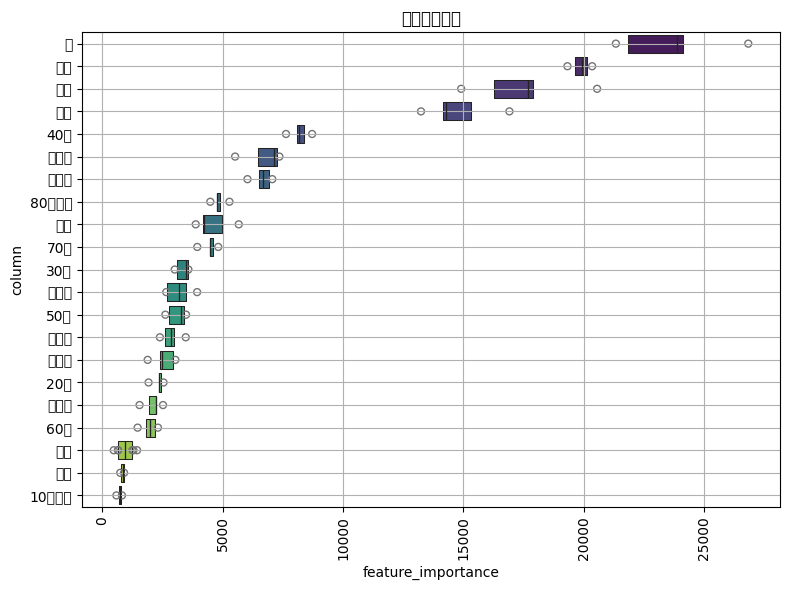

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12499 (\N{KATAKANA LETTER BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


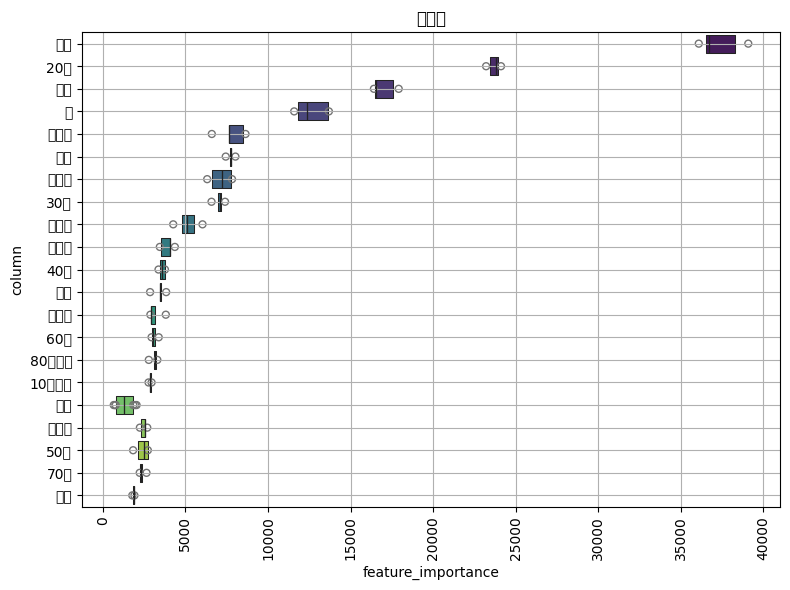

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12504 (\N{KATAKANA LETTER HE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


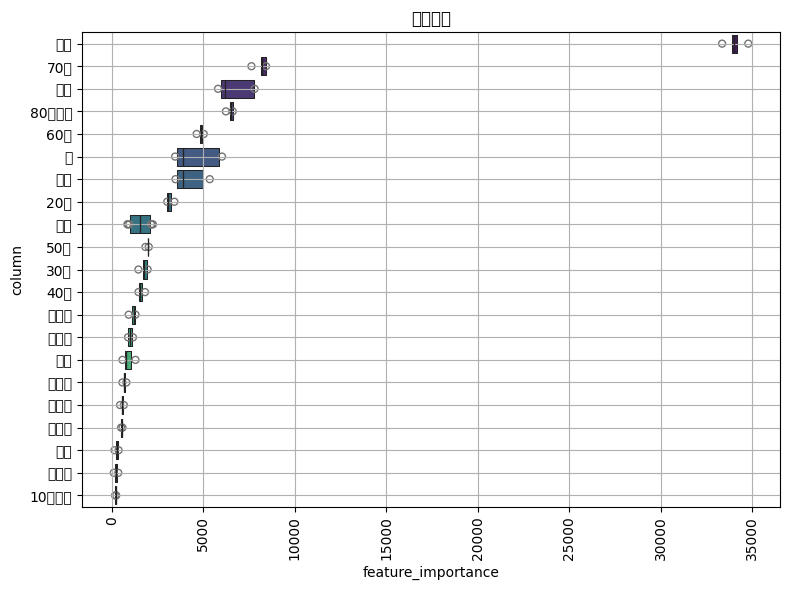

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 13199 (\N{SQUARE KG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


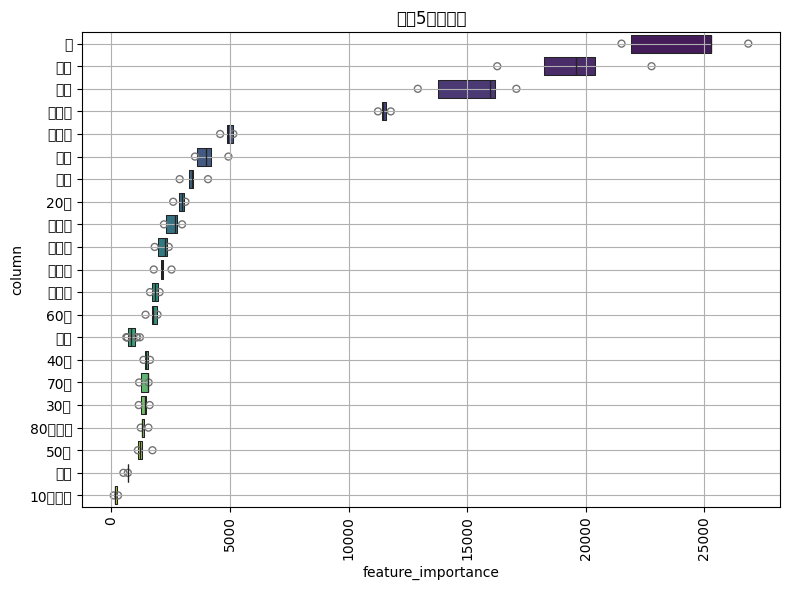

In [ ]:
for col_i, (oof, models) in zip(TARGET_COLUMNS, results):
    fig, ax = visualize_importance(models, train_feat_df)
    ax.set_title(col_i)

In [ ]:
submission_df = pd.DataFrame()

for col_i, (oof, models) in zip(TARGET_COLUMNS, results):
    predicts = [model.predict_proba(test_feat_df.values)[:, 1] for model in models]
    predict_i = np.array(predicts).mean(axis=0)

    submission_df[col_i] = predict_i

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

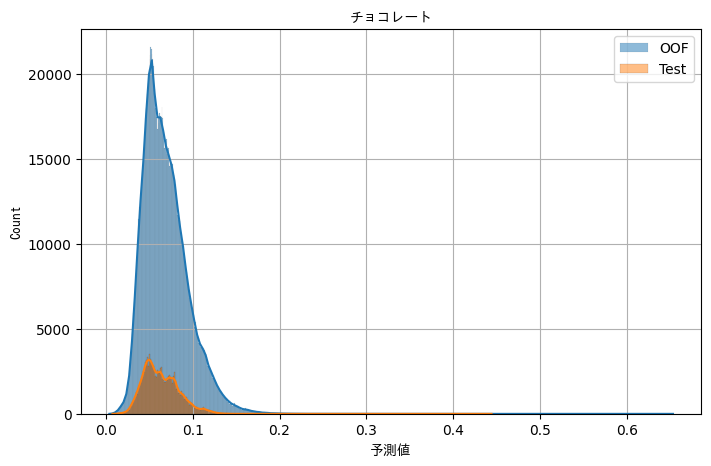

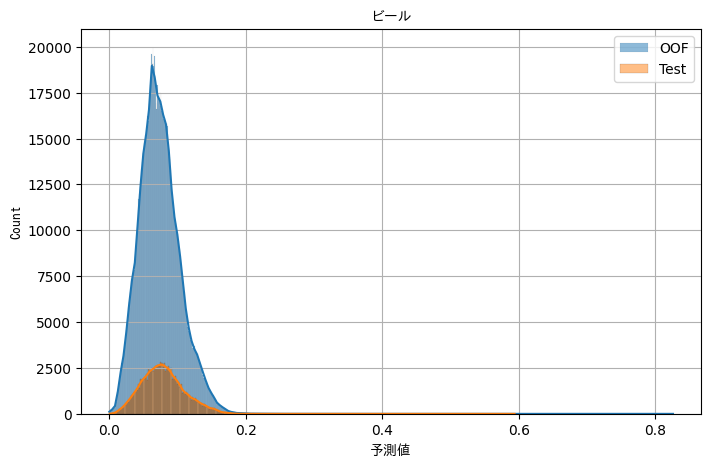

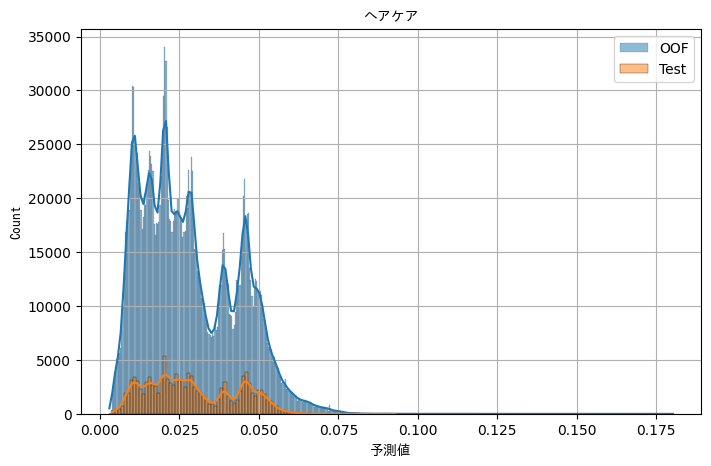

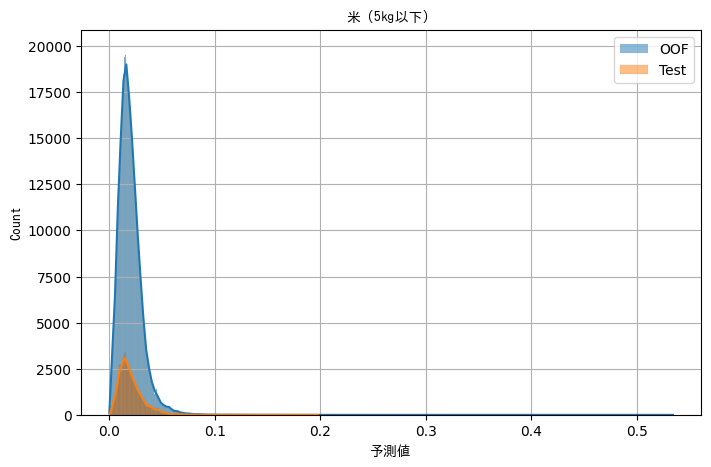

In [ ]:
for c in TARGET_COLUMNS:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(oof_df[c], ax=ax, label="OOF", kde=True)
    sns.histplot(submission_df[c], ax=ax, label="Test", kde=True)

    ax.set_xlabel("予測値", fontproperties=font_prop)  # x軸ラベルの文字化けを防ぐ
    ax.set_ylabel("Count", fontproperties=font_prop)  # y軸ラベルも設定
    ax.set_title(c, fontproperties=font_prop)  # 日本語タイトル対応
    ax.legend()
    ax.grid()

    plt.show()

In [ ]:
import os

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/atma/tutorial_1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
submission_df.to_csv(os.path.join(OUTPUT_DIR, "#3__submission.csv"), index=False)

In [ ]:
rm -rf ~/.cache/matplotlib